# Seasonal Agriculture Performance Analysis Using Python

## Project Overview

Agricultural performance can vary significantly across seasons due to changes in environmental conditions, farming practices, resource availability and market conditions.

This project analyzes agricultural data across different seasons to identify meaningful patterns, trends, relationships and differences in agricultural performance.

The analysis focuses on:

- Seasonal agricultural productivity
- Environmental conditions
- Resource utilization
- Water efficiency
- Economic performance
- Disease and pest risk
- Crop-wise and regional differences
- Relationships between agricultural factors and outcomes

The goal is to derive evidence-based insights and recommendations that can support better seasonal agricultural planning.

## Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons.

Therefore, this project analyzes the available agricultural dataset to investigate seasonal differences and identify meaningful:

- Patterns
- Trends
- Relationships
- Variations
- Productivity differences
- Resource usage differences
- Economic outcomes
- Environmental changes

The analysis aims to generate evidence-based insights that can support better seasonal agricultural planning.

## Objectives

1. Explore and understand the agricultural dataset.
2. Clean and prepare the dataset for analysis.
3. Analyze agricultural performance across seasons.
4. Identify important seasonal patterns and trends.
5. Examine environmental conditions across seasons.
6. Compare resource usage across seasons.
7. Analyze agricultural productivity and yield.
8. Examine economic performance across seasons.
9. Investigate relationships between environmental/resource factors and yield.
10. Compare seasonal performance across crops and regions.
11. Identify unusual or significant patterns.
12. Apply appropriate statistical and visualization techniques.
13. Develop evidence-based insights.
14. Provide data-driven recommendations for seasonal agricultural planning.

**1.Import Libraries**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


**2.Upload Dataset**

In [2]:
import pandas as pd

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
df_raw = df.copy()

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (4000, 28)


**3.Basic Dataset Inspection**

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [4]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
df.tail()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


**4.Identify Categorical and Numerical Columns**

In [8]:
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']

Numerical Columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


**5.Unique Values**

In [9]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


Farm_ID
['SF10001' 'SF10002' 'SF10003' ... 'SF13998' 'SF13999' 'SF14000']

State
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [10]:
for column in categorical_columns:
    print(f"\n{column}: {df[column].nunique()} unique values")


Farm_ID: 4000 unique values

State: 8 unique values

District: 10 unique values

Crop: 8 unique values

Season: 3 unique values

Irrigation_Method: 4 unique values


**6.Duplicate Check**

In [11]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


**7.Missing Value Analysis**

In [12]:
missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

missing_summary = missing_summary[missing_summary['Missing Values'] > 0]

missing_summary.sort_values(
    by='Missing Values',
    ascending=False
)

,Missing Values,Missing Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


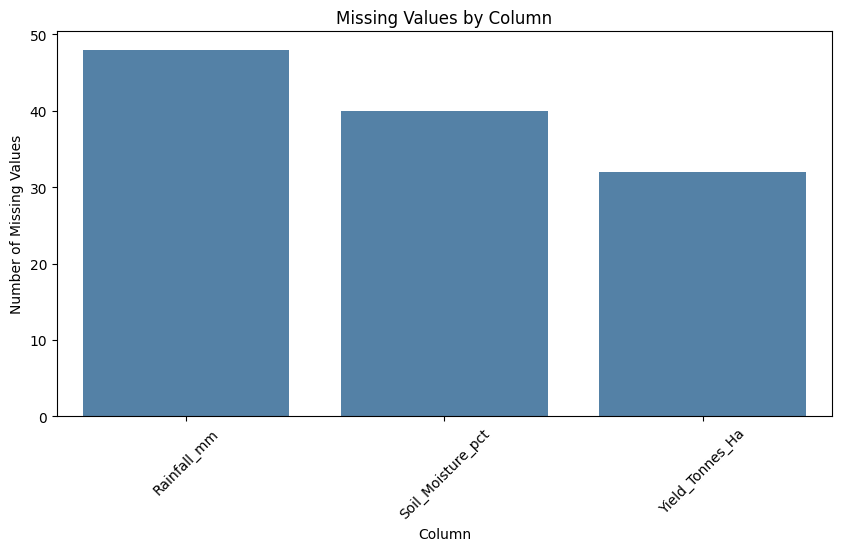

In [13]:
plt.figure(figsize=(10, 5))

sns.barplot(
    color='steelblue',
    x=missing_summary.index,
    y=missing_summary['Missing Values']
)

plt.xticks(rotation=45)
plt.title("Missing Values by Column")
plt.ylabel("Number of Missing Values")
plt.xlabel("Column")

plt.show()

**8.Missing Value Treatment**

In [14]:
missing_columns = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

imputation_record = {}

for column in missing_columns:
    missing_before = df[column].isna().sum()
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)
    imputation_record[column] = {
        'missing_before': missing_before,
        'imputation_value_median': median_value
    }

print("Median imputation completed for numerical columns with missing values.")
pd.DataFrame(imputation_record).T

Median imputation completed for numerical columns with missing values.


,missing_before,imputation_value_median
Rainfall_mm,48.0,582.00
Soil_Moisture_pct,40.0,26.40
Yield_Tonnes_Ha,32.0,1.74


In [15]:
print(df.isnull().sum().sum())

0


**9.Data Validation**

In [16]:
# Check negative values in numerical columns
for column in numerical_columns:
    negative_count = (df[column] < 0).sum()

    if negative_count > 0:
        print(column, ":", negative_count, "negative values")

Profit_INR : 1966 negative values


In [17]:
print("Farm area minimum:", df['Farm_Area_Hectares'].min())
print("Yield minimum:", df['Yield_Tonnes_Ha'].min())
print("Profit minimum:", df['Profit_INR'].min())
print("Rainfall minimum:", df['Rainfall_mm'].min())

Farm area minimum: 0.5
Yield minimum: 0.3
Profit minimum: -1019223
Rainfall minimum: 80.0


**10.Check Data Consistency**

In [18]:
# Validate Production = Farm Area × Yield using the untouched data.
production_check = df_raw[df_raw['Yield_Tonnes_Ha'].notna()].copy()

production_check['Calculated_Production'] = (
    production_check['Farm_Area_Hectares'] *
    production_check['Yield_Tonnes_Ha']
)

production_check['Production_Difference'] = (
    production_check['Production_Tonnes'] -
    production_check['Calculated_Production']
)

production_tolerance = 0.01
within_tolerance = production_check['Production_Difference'].abs() <= production_tolerance

print("Rows checked:", len(production_check))
print("Rows within ±0.01 tonne tolerance:", within_tolerance.sum())
print("Rows outside tolerance:", (~within_tolerance).sum())
print("Maximum absolute difference:",
      round(production_check['Production_Difference'].abs().max(), 6))

production_check[['Production_Tonnes', 'Calculated_Production',
                  'Production_Difference']].head()

Rows checked: 3968
Rows within ±0.01 tonne tolerance: 3968
Rows outside tolerance: 0
Maximum absolute difference: 0.005


,Production_Tonnes,Calculated_Production,Production_Difference
0,1.30,1.3038,-3.800000e-03
1,1.96,1.9590,1.000000e-03
2,2.53,2.5272,2.800000e-03
3,8.28,8.2800,-1.776357e-15
4,9.30,9.3041,-4.100000e-03


In [19]:
production_check['Production_Difference'].describe().round(6)

count    3968.000000
mean        0.000003
std         0.002895
min        -0.005000
25%        -0.002500
50%         0.000000
75%         0.002500
max         0.005000
Name: Production_Difference, dtype: float64

**11.Seasonal Distribution**

In [20]:
season_counts = df['Season'].value_counts()

print(season_counts)

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


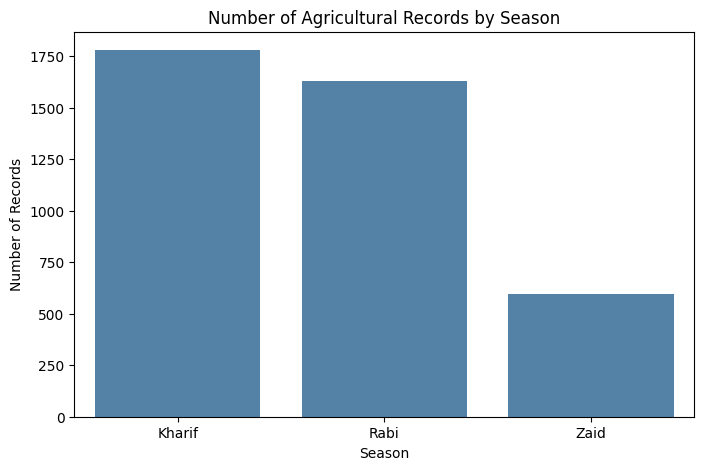

In [21]:
plt.figure(figsize=(8, 5))

sns.countplot(
    color='steelblue',
    data=df,
    x='Season',
    order=df['Season'].value_counts().index
)

plt.title("Number of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.show()

**12.Main Seasonal Performance Analysis**

In [22]:
season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

season_summary


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.63,46.31,710719.06,178914.65,6102.20,5.89,54.47
Rabi,5.04,41.49,601526.05,87689.47,5846.99,5.19,40.48
Zaid,4.64,38.89,519171.90,-24804.82,6419.89,4.41,38.22


**13.Seasonal Yield Analysis**

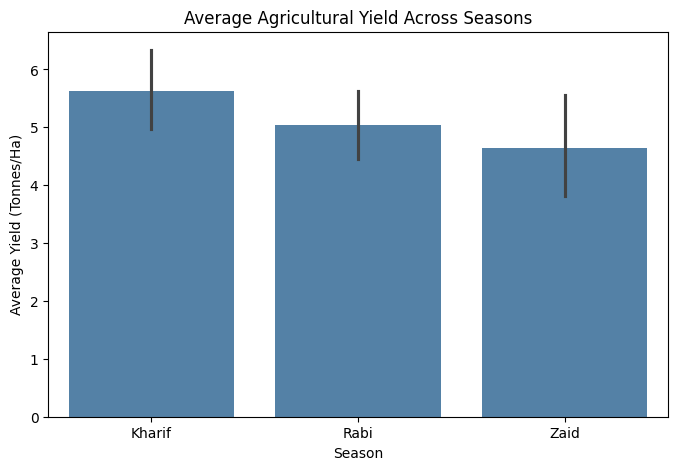

In [23]:
plt.figure(figsize=(8, 5))

sns.barplot(
    color='steelblue',
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='mean'
)

plt.title("Average Agricultural Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.show()

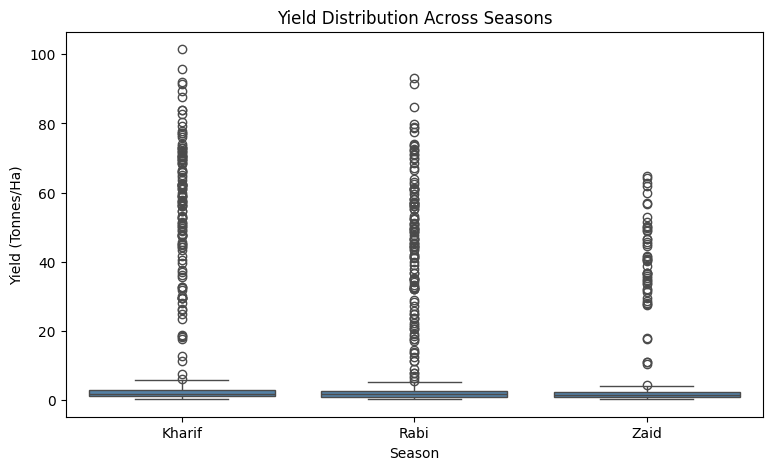

In [24]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    color='steelblue',
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

**14.Seasonal Production**

In [25]:
season_production = df.groupby('Season')['Production_Tonnes'].mean().sort_values(
    ascending=False
)

season_production

Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64

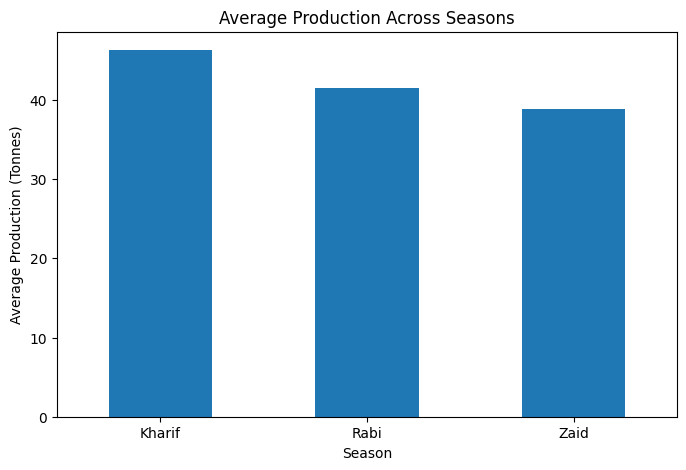

In [26]:
plt.figure(figsize=(8, 5))

season_production.plot(kind='bar')

plt.title("Average Production Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")

plt.xticks(rotation=0)
plt.show()

**15.Environmental Conditions**

In [27]:
environment_summary = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Sunlight_Hours_Day': 'mean',
    'Soil_Moisture_pct': 'mean'
}).round(2)

environment_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


**16.Environmental Visualization**

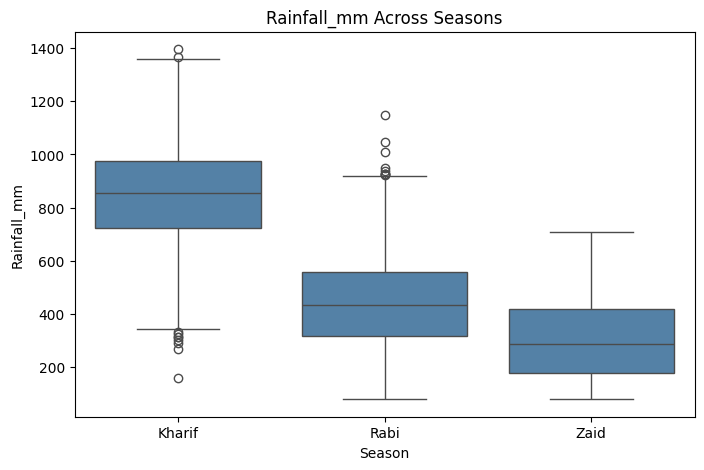

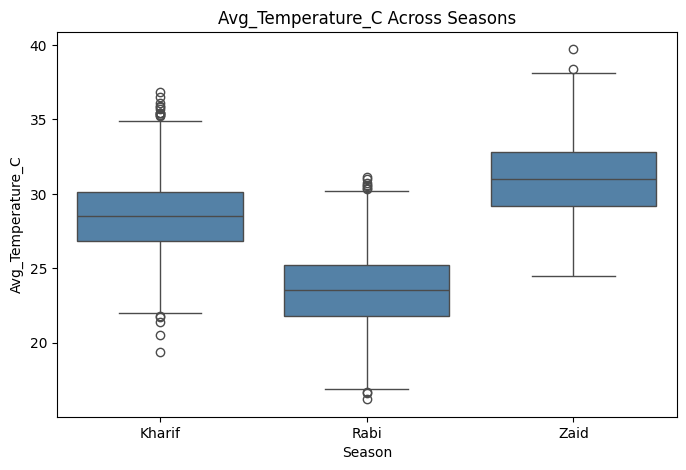

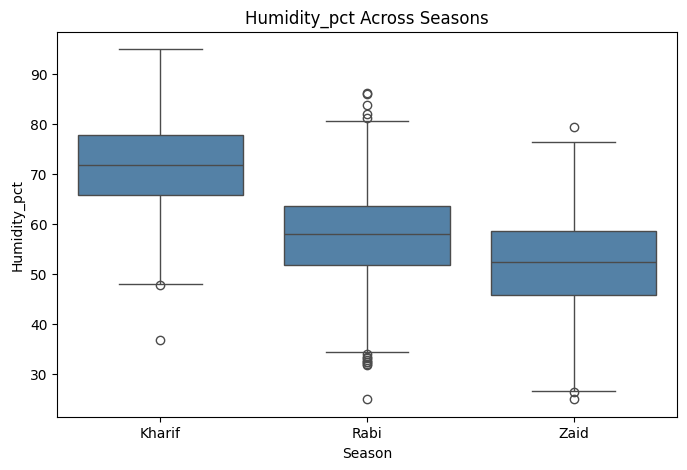

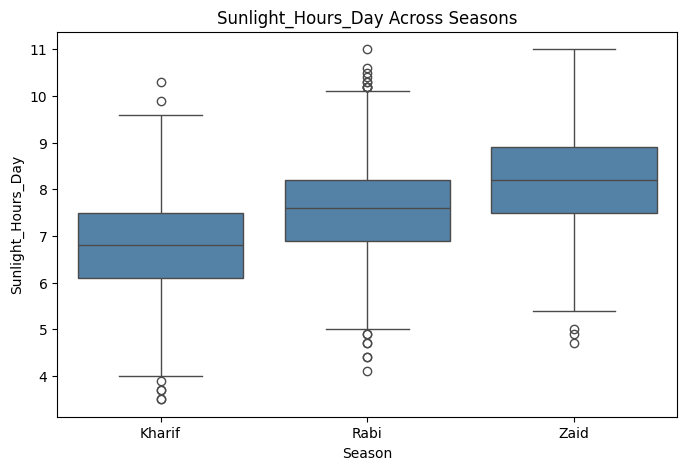

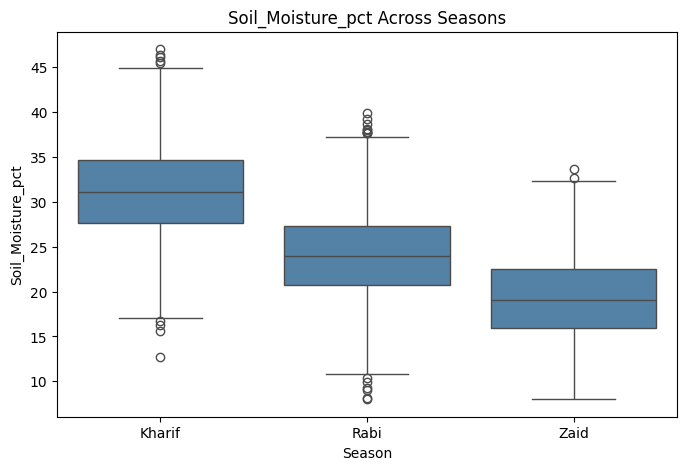

In [28]:
environment_variables = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_Moisture_pct'
]

for variable in environment_variables:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
    color='steelblue',
        data=df,
        x='Season',
        y=variable
    )

    plt.title(f"{variable} Across Seasons")
    plt.xlabel("Season")
    plt.ylabel(variable)

    plt.show()

**17.Resource Usage Analysis**

In [29]:
resource_summary = df.groupby('Season').agg({
    'Nitrogen_kg_ha': 'mean',
    'Phosphorus_kg_ha': 'mean',
    'Potassium_kg_ha': 'mean',
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean',
    'Water_Used_m3': 'mean'
}).round(2)

resource_summary

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,6102.20
Rabi,120.40,57.31,103.93,185.41,5.02,5846.99
Zaid,120.53,58.13,105.42,184.64,5.17,6419.89


**18.Water Efficiency**

In [30]:
water_summary = df.groupby('Season').agg({
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

water_summary

,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,6102.20,5.89
Rabi,5846.99,5.19
Zaid,6419.89,4.41


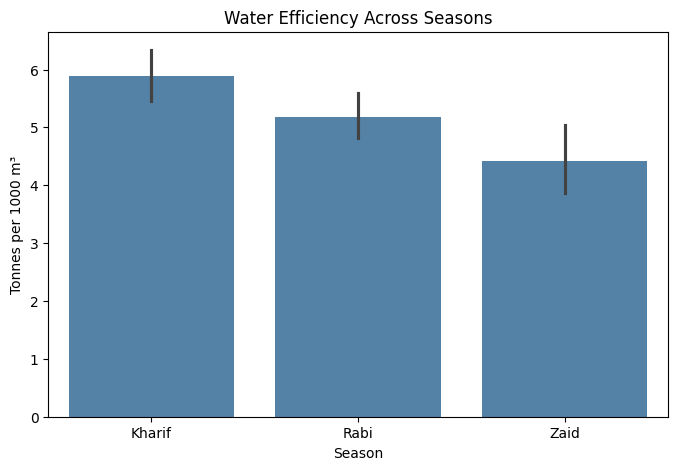

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    color='steelblue',
    data=df,
    x='Season',
    y='Water_Efficiency_t_per_1000m3'
)

plt.title("Water Efficiency Across Seasons")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")

plt.show()

**19.Economic Performance**

In [32]:
economic_summary = df.groupby('Season').agg({
    'Market_Price_INR_Tonne': 'mean',
    'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)

economic_summary

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,
Kharif,44850.91,531804.41,710719.06,178914.65
Rabi,44747.97,513836.58,601526.05,87689.47
Zaid,44212.03,543976.73,519171.90,-24804.82


**20.Profit by Season**

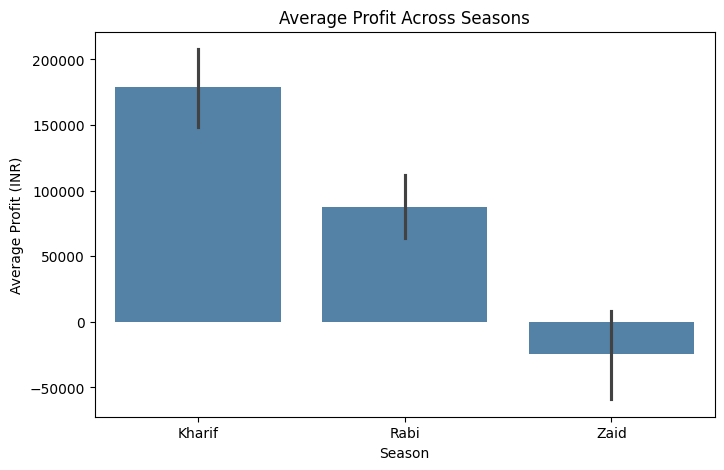

In [33]:
plt.figure(figsize=(8, 5))

sns.barplot(
    color='steelblue',
    data=df,
    x='Season',
    y='Profit_INR'
)

plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.show()

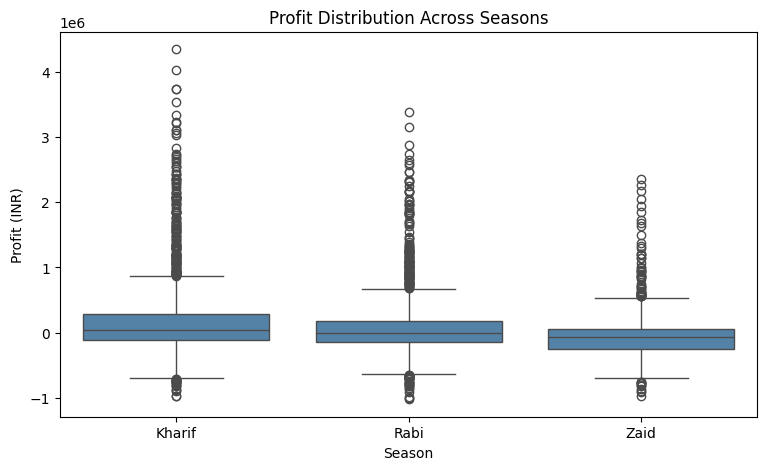

In [34]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    color='steelblue',
    data=df,
    x='Season',
    y='Profit_INR'
)

plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.show()

**22.Profit Margin**

In [35]:
# Farm-level profit margin
df['Profit_Margin_pct'] = np.where(
    df['Revenue_INR'] != 0,
    (df['Profit_INR'] / df['Revenue_INR']) * 100,
    np.nan
)

# Weighted seasonal margin = total seasonal profit / total seasonal revenue.
season_profit_margin = (
    df.groupby('Season')['Profit_INR'].sum()
    / df.groupby('Season')['Revenue_INR'].sum()
) * 100

season_profit_margin = season_profit_margin.round(2)
season_profit_margin

Season
Kharif    25.17
Rabi      14.58
Zaid      -4.78
dtype: float64

In [36]:
profit_margin_summary = season_profit_margin.copy()
profit_margin_summary

Season
Kharif    25.17
Rabi      14.58
Zaid      -4.78
dtype: float64

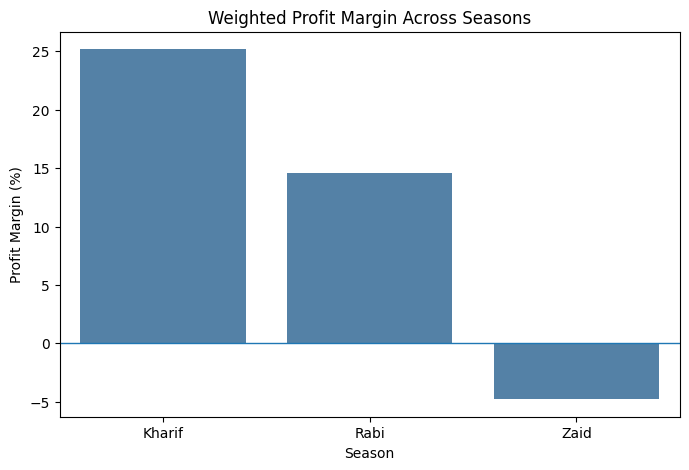

In [37]:
plt.figure(figsize=(8, 5))

sns.barplot(
    color='steelblue',
    x=profit_margin_summary.index,
    y=profit_margin_summary.values
)

plt.title("Weighted Profit Margin Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit Margin (%)")
plt.axhline(0, linewidth=1)

plt.show()

**23.Disease/Pest Risk**

In [38]:
risk_summary = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().sort_values(
    ascending=False
)

risk_summary

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64

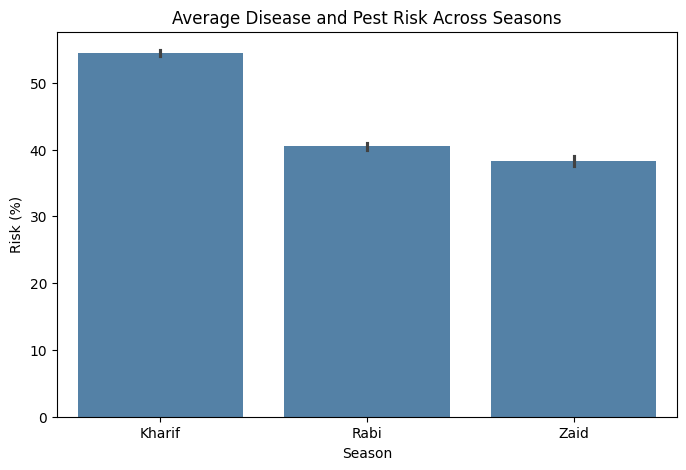

In [39]:
plt.figure(figsize=(8, 5))

sns.barplot(
    color='steelblue',
    data=df,
    x='Season',
    y='Disease_Pest_Risk_pct'
)

plt.title("Average Disease and Pest Risk Across Seasons")
plt.xlabel("Season")
plt.ylabel("Risk (%)")

plt.show()

**24.Irrigation Method Analysis**

In [40]:
irrigation_season = pd.crosstab(
    df['Season'],
    df['Irrigation_Method'],
    normalize='index'
) * 100

irrigation_season.round(2)

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


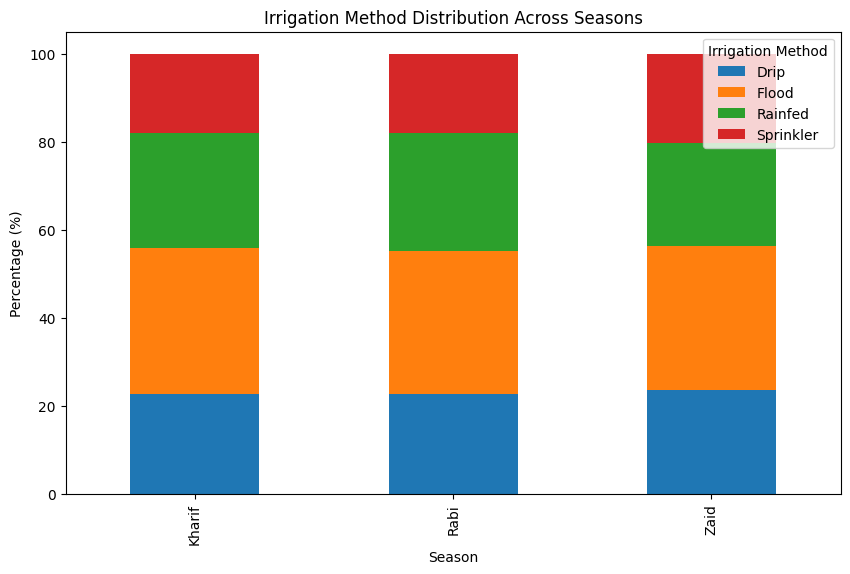

In [41]:
irrigation_season.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title("Irrigation Method Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Percentage (%)")
plt.legend(title="Irrigation Method")

plt.show()

**25.Crop-wise Seasonal Analysis**

In [42]:
crop_season_yield = pd.pivot_table(
    df,
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

crop_season_yield.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


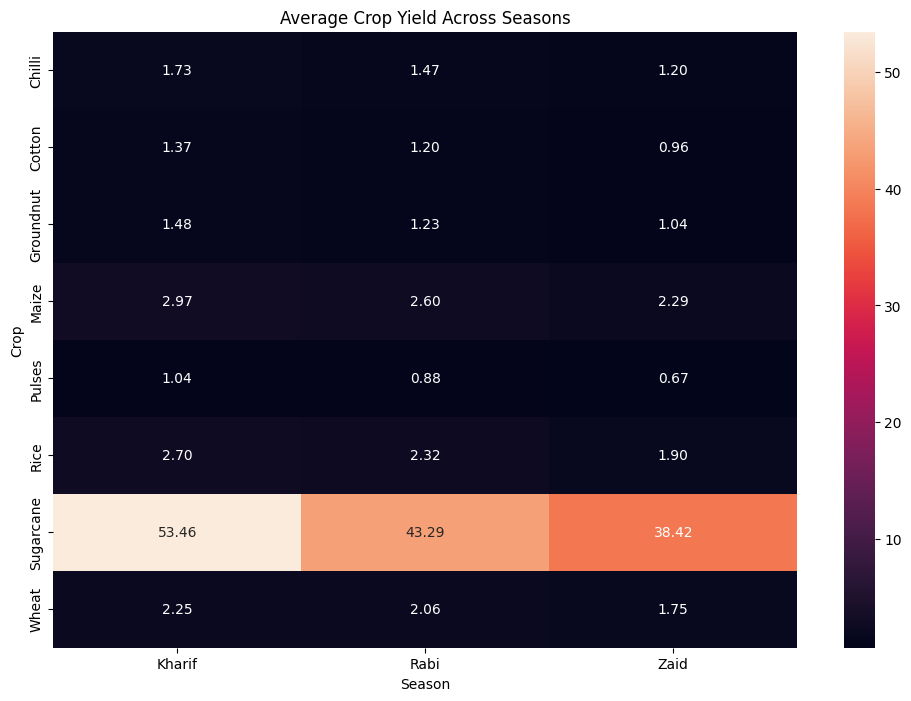

In [43]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f'
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.show()

**26.Best Crop in Each Season**

In [44]:
best_crop_by_season = (
    df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha']
    .mean()
    .reset_index()
)

best_crop_by_season = best_crop_by_season.loc[
    best_crop_by_season.groupby('Season')['Yield_Tonnes_Ha'].idxmax()
]

best_crop_by_season

,Season,Crop,Yield_Tonnes_Ha
6,Kharif,Sugarcane,53.459120
14,Rabi,Sugarcane,43.286124
22,Zaid,Sugarcane,38.423922


**27.Regional Analysis**

In [45]:
state_season_yield = pd.pivot_table(
    df,
    values='Yield_Tonnes_Ha',
    index='State',
    columns='Season',
    aggfunc='mean'
)

state_season_yield.round(2)

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.45
Gujarat,6.34,5.44,4.07
Karnataka,6.46,4.57,6.62
Madhya Pradesh,5.99,3.76,5.48
Maharashtra,5.43,5.50,2.28
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.78,4.25


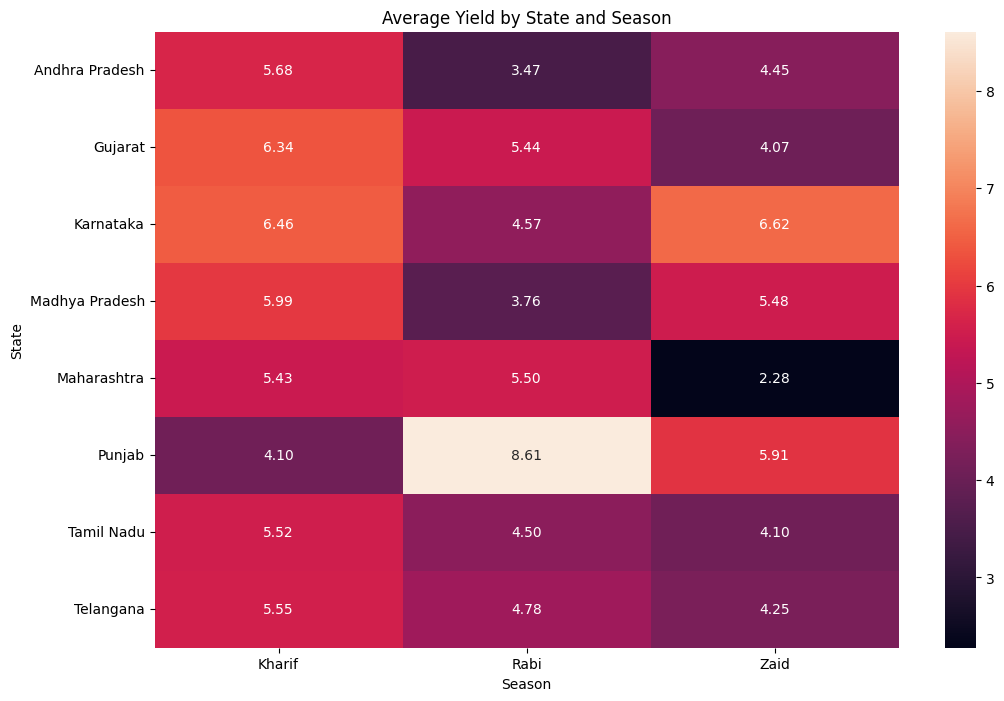

In [46]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    state_season_yield,
    annot=True,
    fmt='.2f'
)

plt.title("Average Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")

plt.show()

**27.Top Performing Regions**

In [47]:
state_performance = df.groupby('State').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).sort_values(
    'Yield_Tonnes_Ha',
    ascending=False
)

state_performance.head(10).round(2)

,Yield_Tonnes_Ha,Profit_INR,Water_Efficiency_t_per_1000m3
State,,,
Punjab,6.12,136025.64,5.62
Karnataka,5.69,119422.34,5.56
Gujarat,5.66,117568.24,5.58
Telangana,5.04,108829.62,5.46
Maharashtra,5.02,135428.86,5.28
Madhya Pradesh,4.99,86840.76,5.27
Tamil Nadu,4.88,117744.75,5.31
Andhra Pradesh,4.63,73453.53,5.03


**28.Correlation Analysis**

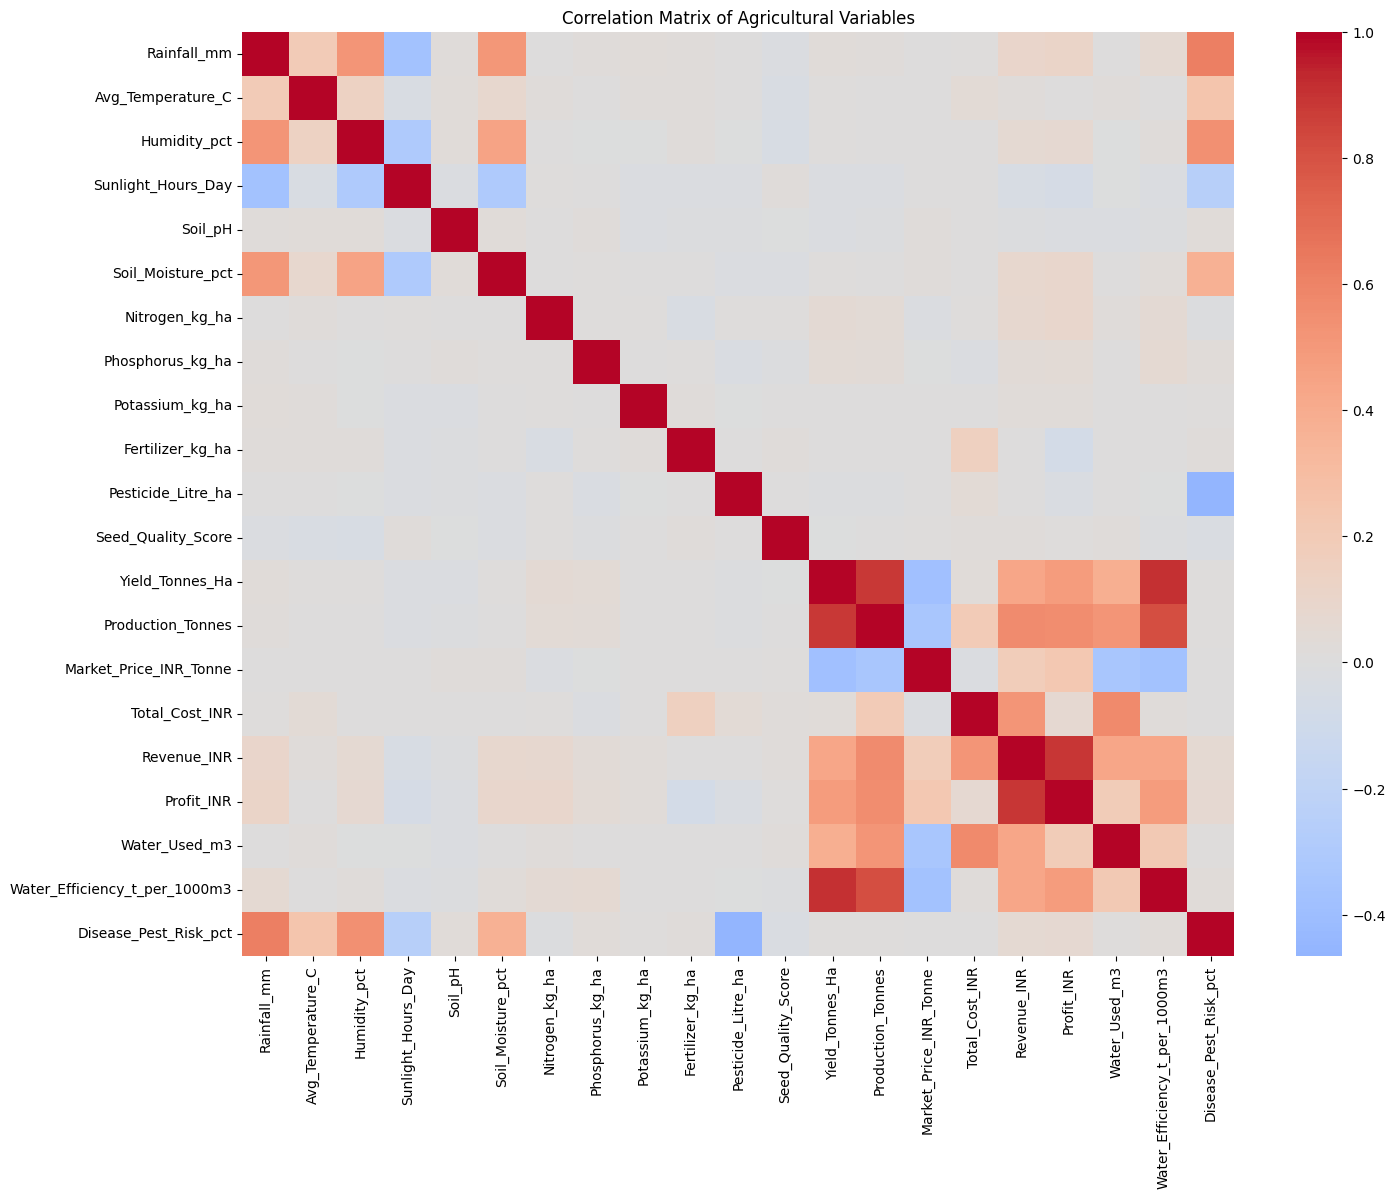

In [48]:
correlation_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.show()

**29.Factors Associated With Yield**

In [49]:
yield_correlations = (
    correlation_matrix['Yield_Tonnes_Ha']
    .sort_values(ascending=False)
)

yield_correlations

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912568
Production_Tonnes                0.882813
Profit_INR                       0.488466
Revenue_INR                      0.432152
Water_Used_m3                    0.386294
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Rainfall_mm                      0.030951
Total_Cost_INR                   0.030622
Disease_Pest_Risk_pct            0.014292
Humidity_pct                     0.012297
Soil_Moisture_pct                0.010999
Avg_Temperature_C                0.009996
Potassium_kg_ha                  0.003382
Fertilizer_kg_ha                 0.000018
Seed_Quality_Score              -0.007209
Pesticide_Litre_ha              -0.007779
Sunlight_Hours_Day              -0.015341
Soil_pH                         -0.020672
Market_Price_INR_Tonne          -0.382607
Name: Yield_Tonnes_Ha, dtype: float64

### Interpretation of Correlation Results

Correlation measures association, not causation. Some very high correlations in this dataset are expected because certain variables are mathematically derived from others. For example, Production depends on Farm Area and Yield, while Water Efficiency depends on Production and Water Used.

Therefore, derived variables should not be interpreted as independent causal drivers of Yield. The next analysis focuses on environmental, resource and management variables that are not directly calculated from Yield.

In [50]:
independent_yield_factors = [
    'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
    'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct',
    'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
    'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
    'Water_Used_m3', 'Disease_Pest_Risk_pct'
]

direct_yield_correlations = (
    df[independent_yield_factors + ['Yield_Tonnes_Ha']]
    .corr()['Yield_Tonnes_Ha']
    .drop('Yield_Tonnes_Ha')
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .round(3)
)

direct_yield_correlations

Water_Used_m3            0.386
Nitrogen_kg_ha           0.053
Phosphorus_kg_ha         0.048
Rainfall_mm              0.031
Soil_pH                 -0.021
Sunlight_Hours_Day      -0.015
Disease_Pest_Risk_pct    0.014
Humidity_pct             0.012
Soil_Moisture_pct        0.011
Avg_Temperature_C        0.010
Pesticide_Litre_ha      -0.008
Seed_Quality_Score      -0.007
Potassium_kg_ha          0.003
Fertilizer_kg_ha         0.000
Name: Yield_Tonnes_Ha, dtype: float64

**30.Statistical Analysis**

In [51]:
season_order = ['Kharif', 'Rabi', 'Zaid']
seasons = [s for s in season_order if s in df['Season'].dropna().unique()]

season_groups = [
    df.loc[df['Season'] == season, 'Yield_Tonnes_Ha'].dropna()
    for season in seasons
]

anova_result = stats.f_oneway(*season_groups)
kruskal_result = stats.kruskal(*season_groups)

print("One-way ANOVA")
print("F-statistic:", round(anova_result.statistic, 4))
print("p-value:", anova_result.pvalue)

print("\nKruskal-Wallis test")
print("H-statistic:", round(kruskal_result.statistic, 4))
print("p-value:", kruskal_result.pvalue)

One-way ANOVA
F-statistic: 1.5439
p-value: 0.21367813841845007

Kruskal-Wallis test
H-statistic: 68.7131
p-value: 1.1999054760748268e-15


In [52]:
alpha = 0.05

print("ANOVA interpretation:")
if anova_result.pvalue < alpha:
    print("Reject H0: mean yield differs significantly across seasons.")
else:
    print("Fail to reject H0: ANOVA does not provide sufficient evidence that seasonal mean yield differs.")

print("\nKruskal-Wallis interpretation:")
if kruskal_result.pvalue < alpha:
    print("Reject H0: yield distributions/ranks differ significantly across seasons.")
else:
    print("Fail to reject H0: no statistically significant distributional difference was detected.")

print("\nNote: Yield is highly right-skewed and contains extreme observations, "
      "so the non-parametric result is an important robustness check.")

ANOVA interpretation:
Fail to reject H0: ANOVA does not provide sufficient evidence that seasonal mean yield differs.

Kruskal-Wallis interpretation:
Reject H0: yield distributions/ranks differ significantly across seasons.

Note: Yield is highly right-skewed and contains extreme observations, so the non-parametric result is an important robustness check.


**31.Seasonal Profit Statistical Test**

In [53]:
profit_groups = [
    df.loc[df['Season'] == season, 'Profit_INR'].dropna()
    for season in seasons
]

profit_anova = stats.f_oneway(*profit_groups)
profit_kruskal = stats.kruskal(*profit_groups)

print("One-way ANOVA for Profit")
print("F-statistic:", round(profit_anova.statistic, 4))
print("p-value:", profit_anova.pvalue)

print("\nKruskal-Wallis test for Profit")
print("H-statistic:", round(profit_kruskal.statistic, 4))
print("p-value:", profit_kruskal.pvalue)

One-way ANOVA for Profit
F-statistic: 34.2918
p-value: 1.7124156677397172e-15

Kruskal-Wallis test for Profit
H-statistic: 101.9261
p-value: 7.362721866797111e-23


In [54]:
if profit_anova.pvalue < 0.05:
    print("ANOVA: seasonal differences in mean profit are statistically significant.")
else:
    print("ANOVA: insufficient evidence that mean profit differs across seasons.")

if profit_kruskal.pvalue < 0.05:
    print("Kruskal-Wallis: profit distributions differ significantly across seasons.")
else:
    print("Kruskal-Wallis: insufficient evidence of distributional differences across seasons.")

ANOVA: seasonal differences in mean profit are statistically significant.
Kruskal-Wallis: profit distributions differ significantly across seasons.


**32.Outlier Analysis**

In [55]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound

In [56]:
yield_outliers, yield_lower, yield_upper = detect_outliers_iqr(
    df, 'Yield_Tonnes_Ha'
)

print("Overall yield outlier bounds:")
print("Lower bound:", round(yield_lower, 3))
print("Upper bound:", round(yield_upper, 3))
print("Number of yield outliers:", len(yield_outliers))
print("Percentage of rows flagged:", round(len(yield_outliers) / len(df) * 100, 2), "%")

season_outlier_summary = []

for season in seasons:
    season_data = df[df['Season'] == season]
    outliers, lower, upper = detect_outliers_iqr(
        season_data, 'Yield_Tonnes_Ha'
    )
    season_outlier_summary.append({
        'Season': season,
        'Lower_Bound': lower,
        'Upper_Bound': upper,
        'Outlier_Count': len(outliers),
        'Outlier_Percentage': len(outliers) / len(season_data) * 100
    })

season_outlier_summary = pd.DataFrame(season_outlier_summary).round(3)
season_outlier_summary

Overall yield outlier bounds:
Lower bound: -1.62
Upper bound: 5.5
Number of yield outliers: 302
Percentage of rows flagged: 7.55 %


,Season,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,Kharif,-1.700,5.980,121,6.802
1,Rabi,-1.548,5.313,125,7.683
2,Zaid,-1.270,4.410,50,8.418


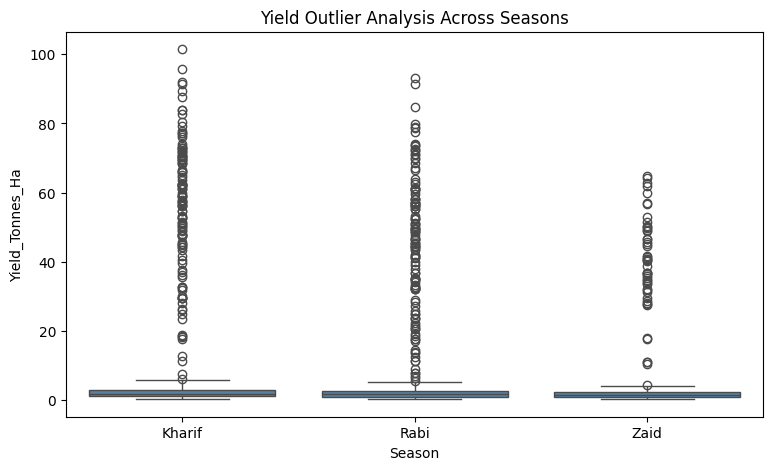

In [57]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    color='steelblue',
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title("Yield Outlier Analysis Across Seasons")

plt.show()

**33.Identify Unusual Seasonal Patterns**

In [58]:
seasonal_metrics = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
})

seasonal_metrics

,Yield_Tonnes_Ha,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,
Kharif,5.628612,178914.647555,5.891834,54.467903
Rabi,5.039435,87689.470191,5.186122,40.482114
Zaid,4.641313,-24804.824916,4.413239,38.216667


In [59]:
seasonal_rankings = pd.DataFrame(index=seasonal_metrics.index)

seasonal_rankings['Yield_Rank'] = seasonal_metrics['Yield_Tonnes_Ha'].rank(ascending=False)
seasonal_rankings['Profit_Rank'] = seasonal_metrics['Profit_INR'].rank(ascending=False)
seasonal_rankings['Water_Efficiency_Rank'] = seasonal_metrics['Water_Efficiency_t_per_1000m3'].rank(ascending=False)
seasonal_rankings['Risk_Rank'] = seasonal_metrics['Disease_Pest_Risk_pct'].rank(ascending=True)

seasonal_rankings.astype(int)

,Yield_Rank,Profit_Rank,Water_Efficiency_Rank,Risk_Rank
Season,,,,
Kharif,1,1,1,3
Rabi,2,2,2,2
Zaid,3,3,3,1


**34.Create an Overall Seasonal Score**

In [60]:
from sklearn.preprocessing import MinMaxScaler

# Custom Composite Seasonal Performance Score.
# Equal weights are assigned to average yield, weighted profit margin,
# and average water efficiency. This is a project-specific comparative index.

composite_metrics = pd.DataFrame({
    'Average_Yield': df.groupby('Season')['Yield_Tonnes_Ha'].mean(),
    'Weighted_Profit_Margin': season_profit_margin,
    'Average_Water_Efficiency': df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean()
})

scaler = MinMaxScaler()

normalized_scores = pd.DataFrame(
    scaler.fit_transform(composite_metrics),
    columns=composite_metrics.columns,
    index=composite_metrics.index
)

normalized_scores['Composite_Score'] = normalized_scores.mean(axis=1)

composite_result = normalized_scores.sort_values(
    'Composite_Score',
    ascending=False
).round(3)

composite_result

,Average_Yield,Weighted_Profit_Margin,Average_Water_Efficiency,Composite_Score
Season,,,,
Kharif,1.000,1.000,1.000,1.000
Rabi,0.403,0.646,0.523,0.524
Zaid,0.000,0.000,0.000,0.000


## 35. Key Insights and Evidence-Based Findings

The following sections convert the analytical outputs into specific, data-supported findings rather than generic observations.

Best season by yield

In [61]:
best_yield_season = (
    df.groupby('Season')['Yield_Tonnes_Ha']
    .mean()
    .idxmax()
)

best_yield_value = (
    df.groupby('Season')['Yield_Tonnes_Ha']
    .mean()
    .max()
)

print(
    f"Highest average yield: {best_yield_season} "
    f"({best_yield_value:.2f} tonnes/ha)"
)

Highest average yield: Kharif (5.63 tonnes/ha)


Best season by profit

In [62]:
best_profit_season = (
    df.groupby('Season')['Profit_INR']
    .mean()
    .idxmax()
)

best_profit_value = (
    df.groupby('Season')['Profit_INR']
    .mean()
    .max()
)

print(
    f"Highest average profit: {best_profit_season} "
    f"({best_profit_value:.2f} INR)"
)

Highest average profit: Kharif (178914.65 INR)


Best water efficiency

In [63]:
best_water_season = (
    df.groupby('Season')['Water_Efficiency_t_per_1000m3']
    .mean()
    .idxmax()
)

print("Highest water efficiency:", best_water_season)

Highest water efficiency: Kharif


In [64]:
loss_rate = (
    df.assign(Loss_Making=df['Profit_INR'] < 0)
      .groupby('Season')['Loss_Making']
      .mean()
      .mul(100)
)

final_seasonal_summary = df.groupby('Season').agg(
    Records=('Farm_ID', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Median_Yield=('Yield_Tonnes_Ha', 'median'),
    Avg_Production=('Production_Tonnes', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water_Use=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
).round(2)

final_seasonal_summary['Weighted_Profit_Margin_pct'] = season_profit_margin
final_seasonal_summary['Loss_Making_Farms_pct'] = loss_rate.round(2)

final_seasonal_summary

,Records,Avg_Yield,Median_Yield,Avg_Production,Avg_Revenue,Avg_Profit,Avg_Water_Use,Avg_Water_Efficiency,Avg_Disease_Risk,Weighted_Profit_Margin_pct,Loss_Making_Farms_pct
Season,,,,,,,,,,,
Kharif,1779,5.63,1.94,46.31,710719.06,178914.65,6102.20,5.89,54.47,25.17,42.21
Rabi,1627,5.04,1.67,41.49,601526.05,87689.47,5846.99,5.19,40.48,14.58,51.14
Zaid,594,4.64,1.46,38.89,519171.90,-24804.82,6419.89,4.41,38.22,-4.78,64.48


## Conclusion

This project analyzed 4,000 agricultural records across Kharif, Rabi and Zaid seasons to identify seasonal differences in agricultural performance, environmental conditions, resource usage and economic outcomes.

### Major Findings

- **Kharif shows the strongest overall performance** on the selected metrics. It has the highest average yield (5.63 tonnes/ha), highest average profit (₹178,914.65) and highest average water efficiency (5.89 tonnes per 1,000 m³).
- **Zaid shows the weakest economic performance**, with an average profit of approximately **-₹24,804.82** and the highest share of loss-making farms at approximately **64.48%**.
- The weighted seasonal profit margin is approximately **25.17% for Kharif, 14.58% for Rabi and -4.78% for Zaid**.
- Environmental conditions differ clearly by season. Kharif has the highest average rainfall, humidity and soil moisture, while Zaid has the highest average temperature and lowest soil moisture.
- Resource-use variables such as nitrogen, phosphorus, potassium and fertilizer application show comparatively smaller seasonal differences than the environmental variables.
- **Sugarcane has much higher yield than the other crops**, so overall seasonal yield averages should be interpreted carefully. Crop-wise comparisons are therefore important.
- Regional performance varies by season, showing that agricultural planning should consider both **season and location**.
- Correlation analysis identifies associations, but mathematically derived variables such as Production and Water Efficiency should not be interpreted as independent causal drivers of Yield.
- One-way ANOVA did not find sufficient evidence of a difference in mean yield across seasons at the 5% significance level (**p ≈ 0.214**). However, the **Kruskal-Wallis test was highly significant (p < 0.001)**, indicating differences in the yield distributions/ranks. This difference is important because yield is strongly skewed and contains extreme observations.
- Both ANOVA and Kruskal-Wallis tests indicate **statistically significant seasonal differences in profit** (p < 0.001).

### Data-Driven Recommendations

1. **Investigate Zaid-season profitability:** The high loss-making rate and negative average profit indicate a need to examine costs, water requirements, crop selection and market conditions during Zaid.
2. **Promote crop-specific seasonal planning:** Because crops have very different yield levels, seasonal recommendations should be made at the crop level rather than from overall yield averages alone.
3. **Use regional-season strategies:** State-level results show that the best-performing season can vary by region, so agricultural planning should consider local conditions.
4. **Improve water management:** Zaid has the lowest average water efficiency, making irrigation efficiency an important area for further investigation.
5. **Monitor environmental conditions:** Rainfall, soil moisture, temperature and humidity vary considerably across seasons and should be considered when evaluating seasonal performance.
6. **Use robust statistics for highly skewed variables:** Yield and profit contain extreme observations, so both classical and non-parametric methods should be considered when comparing seasons.

### Limitations

- The number of observations is unequal across seasons, with fewer Zaid records than Kharif and Rabi.
- The dataset contains missing values in Rainfall, Soil Moisture and Yield, which were handled using median imputation.
- Yield and profit distributions contain extreme observations, which can affect mean-based statistics.
- Correlation measures association and does not prove causation.
- The Composite Seasonal Performance Score is a custom index using equal weights for yield, weighted profit margin and water efficiency; it should be interpreted as a comparative project metric rather than a universal agricultural standard.

Overall, the analysis demonstrates that **seasonal agricultural performance is multidimensional**. Yield, profitability, water efficiency, environmental conditions, crop type and region should be considered together to support evidence-based seasonal agricultural planning.